In [1]:
!pip install pandas numpy matplotlib seaborn wordcloud scikit-learn nltk

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import sys
!{sys.executable} -m pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import re
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Load the dataset
df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Documents\CodeAlpha_SentimentAnalysis\Combined Data.csv")

# Preview the first 5 rows
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (53043, 3)

First 5 rows:


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [5]:
# Check column names, data types and missing values
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nUnique mental health statuses:")
print(df['status'].unique())

Column names: ['Unnamed: 0', 'statement', 'status']

Data types:
Unnamed: 0     int64
statement     object
status        object
dtype: object

Missing values per column:
Unnamed: 0      0
statement     362
status          0
dtype: int64

Unique mental health statuses:
['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


In [6]:
# Drop the useless index column
df = df.drop(columns=['Unnamed: 0'])

# Remove rows where statement is missing
df = df.dropna(subset=['statement'])

# Reset the index after dropping rows
df = df.reset_index(drop=True)

# Confirm the cleaning worked
print("New shape:", df.shape)
print("Missing values remaining:")
print(df.isnull().sum())

New shape: (52681, 2)
Missing values remaining:
statement    0
status       0
dtype: int64


status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64


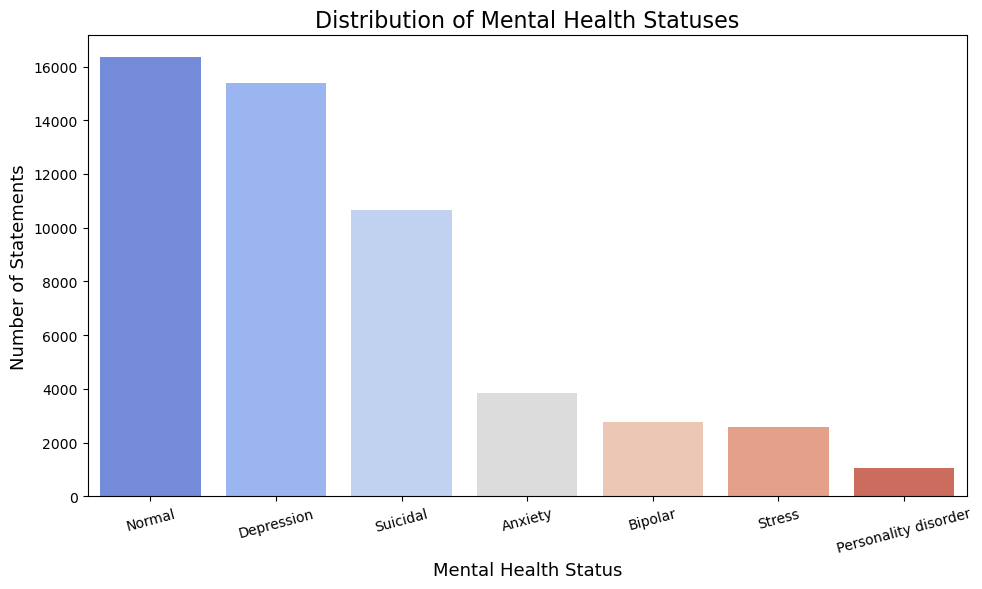

In [7]:
# Count how many statements exist per status
status_counts = df['status'].value_counts()
print(status_counts)

# Plot a bar chart of the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='coolwarm')
plt.title('Distribution of Mental Health Statuses', fontsize=16)
plt.xlabel('Mental Health Status', fontsize=13)
plt.ylabel('Number of Statements', fontsize=13)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [8]:
# Download the list of stopwords (filler words) from nltk
nltk.download('stopwords')

# Define our text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

# Apply the cleaning function to every statement in our dataset
df['cleaned_statement'] = df['statement'].apply(clean_text)

# Preview the result
print("Original statement:")
print(df['statement'][1])
print("\nCleaned statement:")
print(df['cleaned_statement'][1])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original statement:
trouble sleeping, confused mind, restless heart. All out of tune

Cleaned statement:
trouble sleeping confused mind restless heart tune


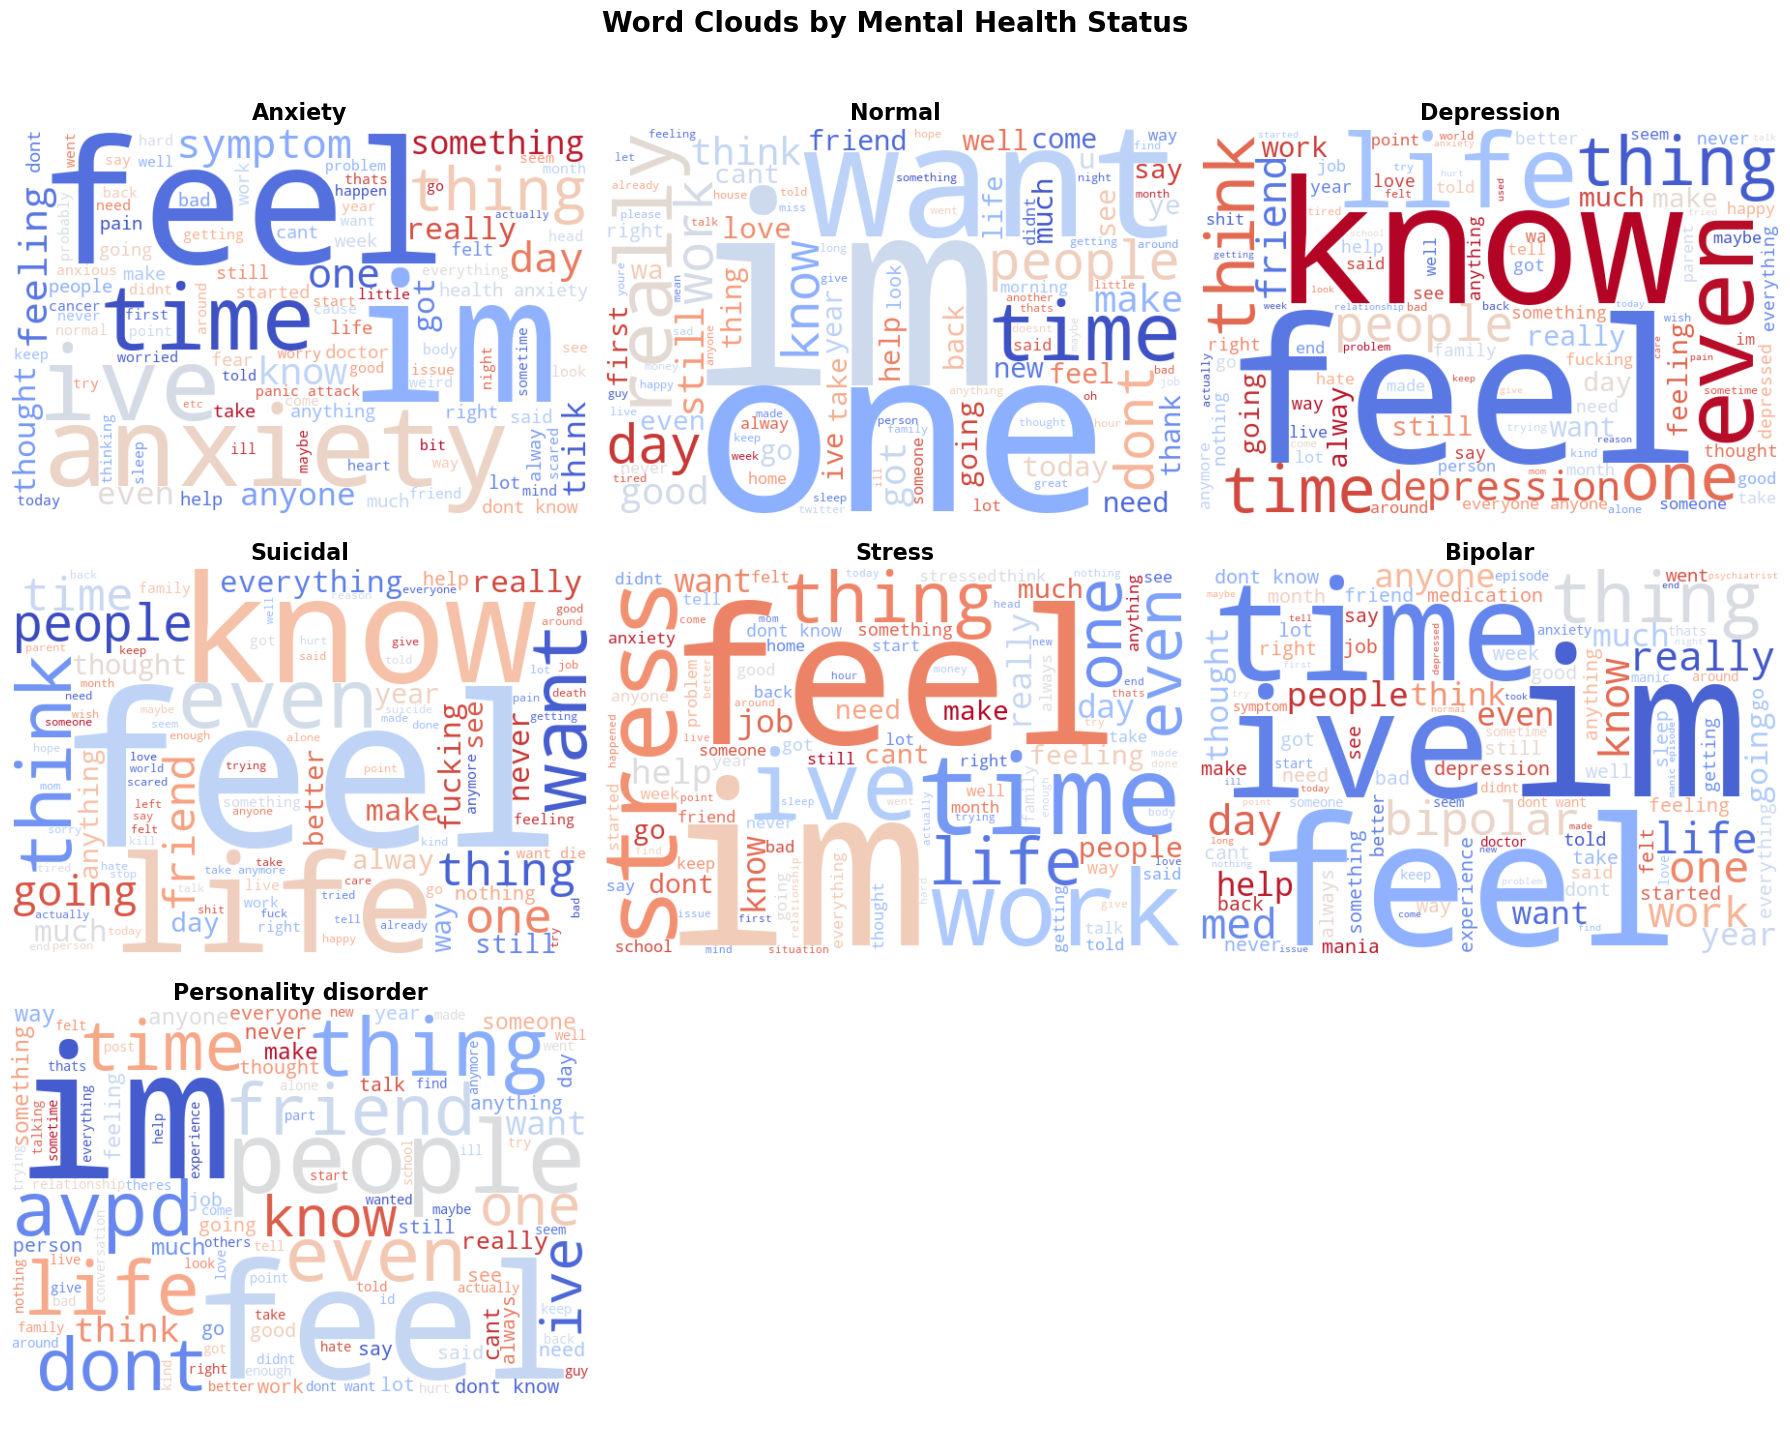

In [9]:
# Get the list of all unique statuses
statuses = df['status'].unique()

# Set up a grid of 7 word clouds (one per status)
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# Loop through each status and generate a word cloud
for i, status in enumerate(statuses):
    # Get all cleaned statements for this status
    text = ' '.join(df[df['status'] == status]['cleaned_statement'])
    
    # Generate the word cloud
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='coolwarm',
        max_words=100
    ).generate(text)
    
    # Display it
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(status, fontsize=16, fontweight='bold')
    axes[i].axis('off')

# Hide the empty 8th and 9th subplot (we only have 7 statuses)
for j in range(len(statuses), len(axes)):
    axes[j].axis('off')

plt.suptitle('Word Clouds by Mental Health Status', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

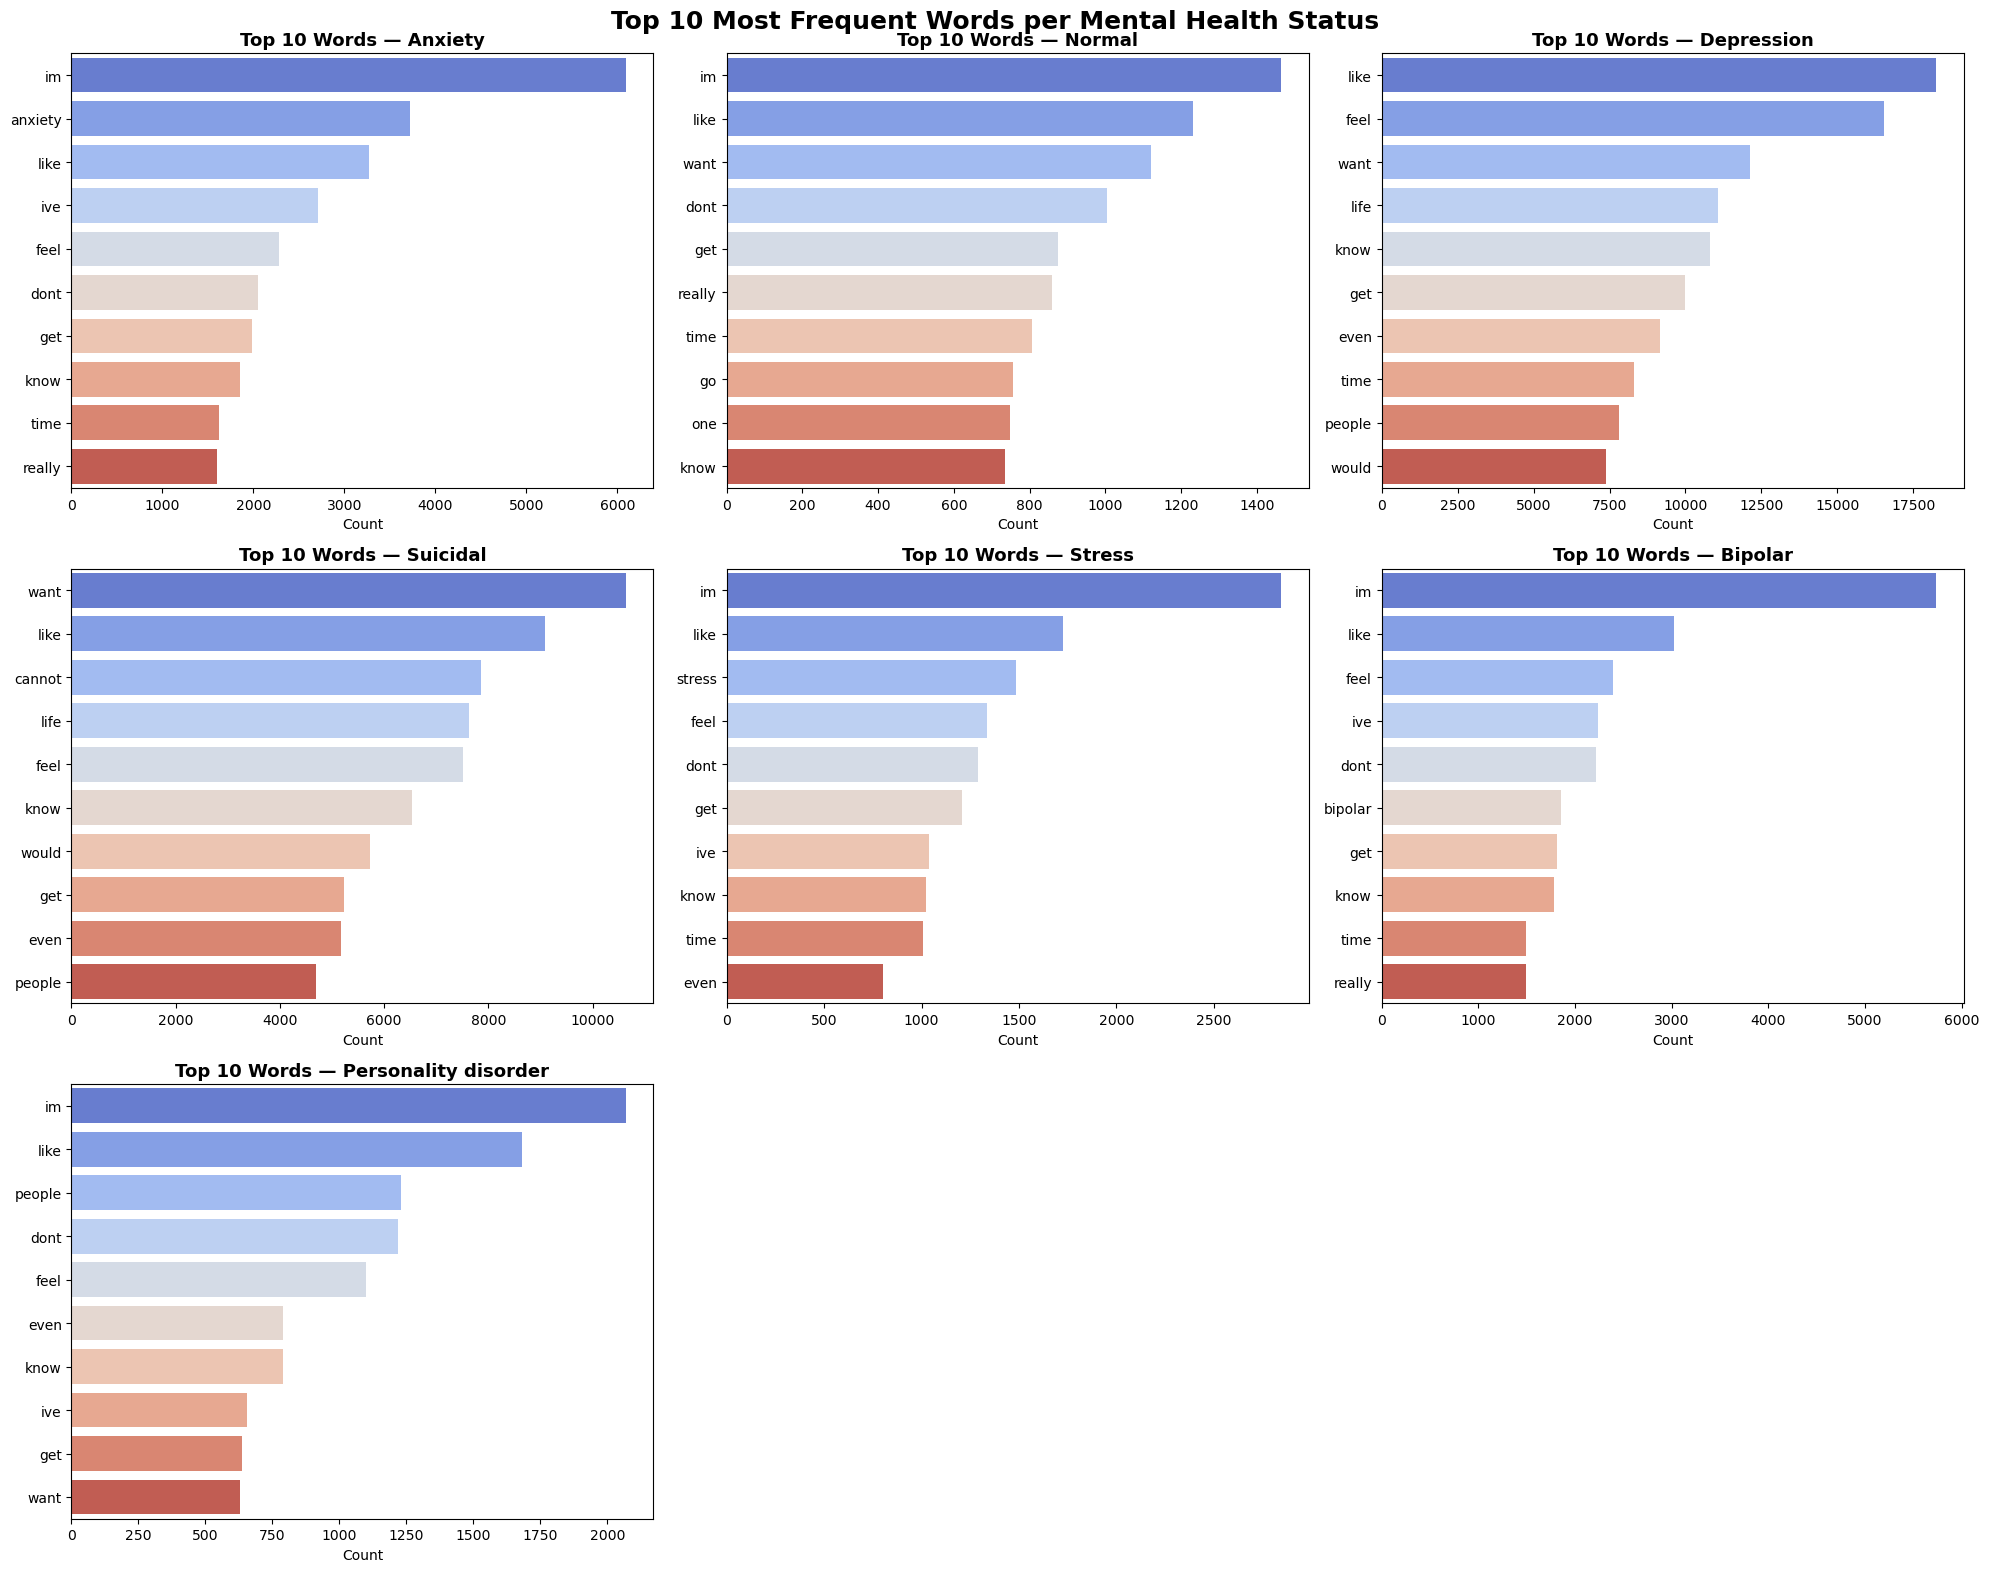

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# Set up the grid
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

# Loop through each status
for i, status in enumerate(statuses):
    # Get cleaned statements for this status
    subset = df[df['status'] == status]['cleaned_statement']
    
    # Count the most common words
    vectorizer = CountVectorizer(max_features=10)
    word_counts = vectorizer.fit_transform(subset)
    words = vectorizer.get_feature_names_out()
    counts = word_counts.toarray().sum(axis=0)
    
    # Sort from highest to lowest
    sorted_idx = counts.argsort()[::-1]
    words = words[sorted_idx]
    counts = counts[sorted_idx]
    
    # Plot
    sns.barplot(x=counts, y=words, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'Top 10 Words — {status}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

# Hide empty subplots
for j in range(len(statuses), len(axes)):
    axes[j].axis('off')

plt.suptitle('Top 10 Most Frequent Words per Mental Health Status', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Define our input (X) and output (y)
X = df['cleaned_statement']
y = df['status']

# Step 2: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 42144
Testing set size: 10537


In [12]:
# Step 3: Convert text into numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Step 4: Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
# Step 5: Test the model and evaluate performance
y_pred = model.predict(X_test_tfidf)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.82      0.77      0.79       755
             Bipolar       0.85      0.74      0.79       527
          Depression       0.70      0.73      0.72      3016
              Normal       0.84      0.95      0.89      3308
Personality disorder       0.86      0.49      0.63       237
              Stress       0.72      0.49      0.58       536
            Suicidal       0.68      0.64      0.66      2158

            accuracy                           0.76     10537
           macro avg       0.78      0.69      0.72     10537
        weighted avg       0.76      0.76      0.76     10537



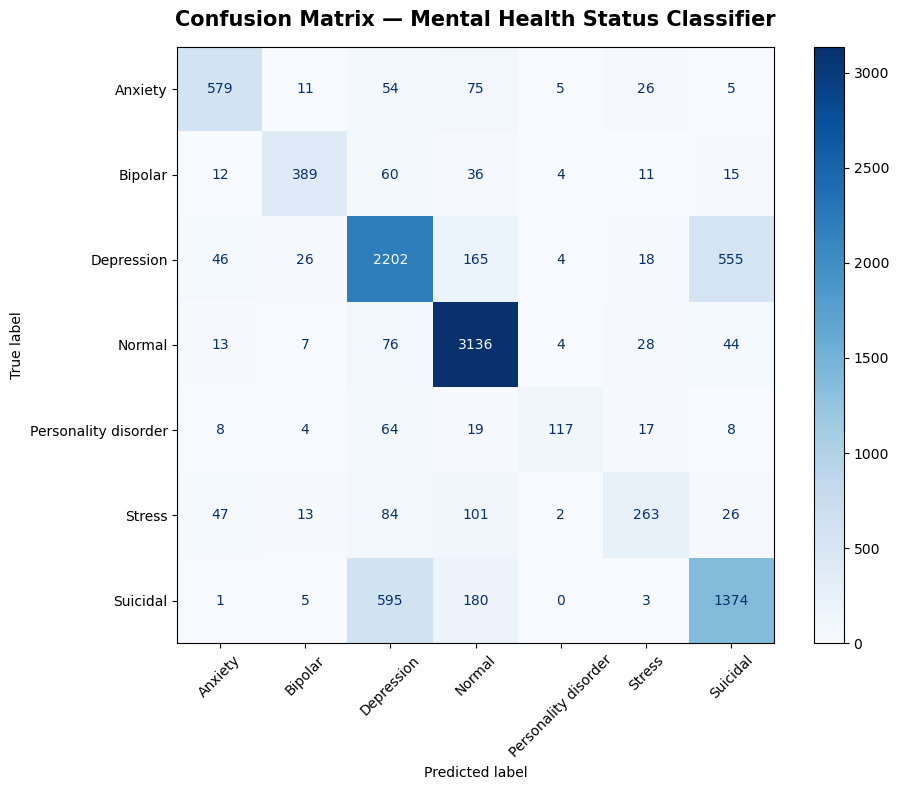

In [14]:
# Plot the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=model.classes_,
    cmap='Blues',
    ax=ax,
    xticks_rotation=45
)

ax.set_title('Confusion Matrix — Mental Health Status Classifier', 
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [15]:
# Test the model on custom input sentences
def predict_mental_health(text):
    cleaned = clean_text(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    confidence = round(max(probability) * 100, 2)
    print(f"Statement: '{text}'")
    print(f"Predicted Status: {prediction}")
    print(f"Confidence: {confidence}%")
    print("-" * 50)

# Try some example statements
predict_mental_health("I can't sleep and my heart is always racing")
predict_mental_health("I feel hopeless and empty every single day")
predict_mental_health("I'm doing really well, enjoying life and work")
predict_mental_health("I can't take this pressure from school anymore")

Statement: 'I can't sleep and my heart is always racing'
Predicted Status: Normal
Confidence: 54.58%
--------------------------------------------------
Statement: 'I feel hopeless and empty every single day'
Predicted Status: Depression
Confidence: 56.14%
--------------------------------------------------
Statement: 'I'm doing really well, enjoying life and work'
Predicted Status: Normal
Confidence: 75.21%
--------------------------------------------------
Statement: 'I can't take this pressure from school anymore'
Predicted Status: Normal
Confidence: 30.15%
--------------------------------------------------


In [16]:
import os

# Create a folder to save all our charts
output_folder = r"C:\Users\LENOVO\OneDrive\Documents\CodeAlpha_SentimentAnalysis\charts"
os.makedirs(output_folder, exist_ok=True)

print("Charts folder created at:", output_folder)

Charts folder created at: C:\Users\LENOVO\OneDrive\Documents\CodeAlpha_SentimentAnalysis\charts


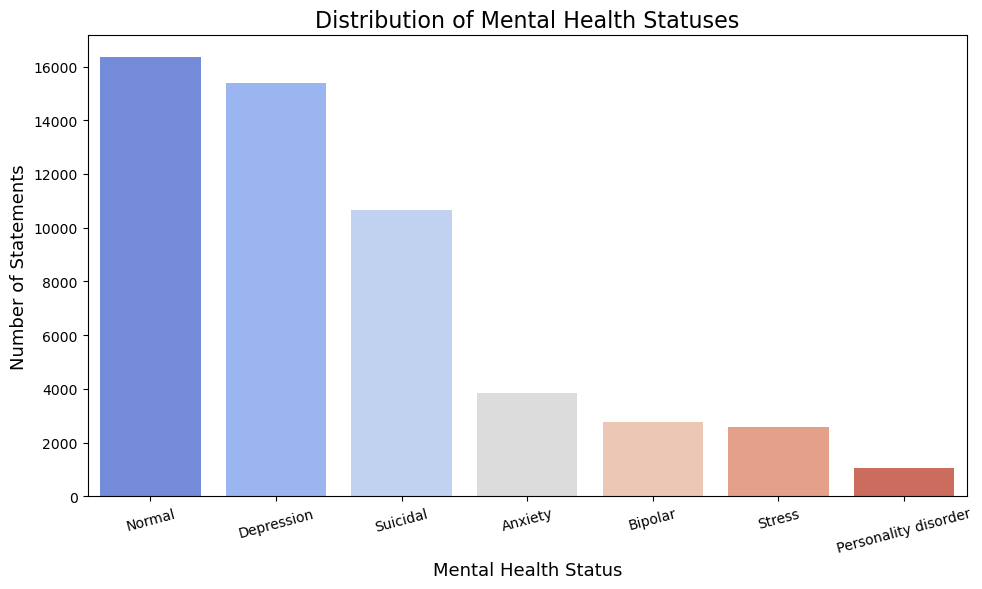

Chart 1 saved!


In [17]:
# Save the status distribution bar chart
status_counts = df['status'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, palette='coolwarm')
plt.title('Distribution of Mental Health Statuses', fontsize=16)
plt.xlabel('Mental Health Status', fontsize=13)
plt.ylabel('Number of Statements', fontsize=13)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, '1_status_distribution.png'), dpi=150)
plt.show()
print("Chart 1 saved!")

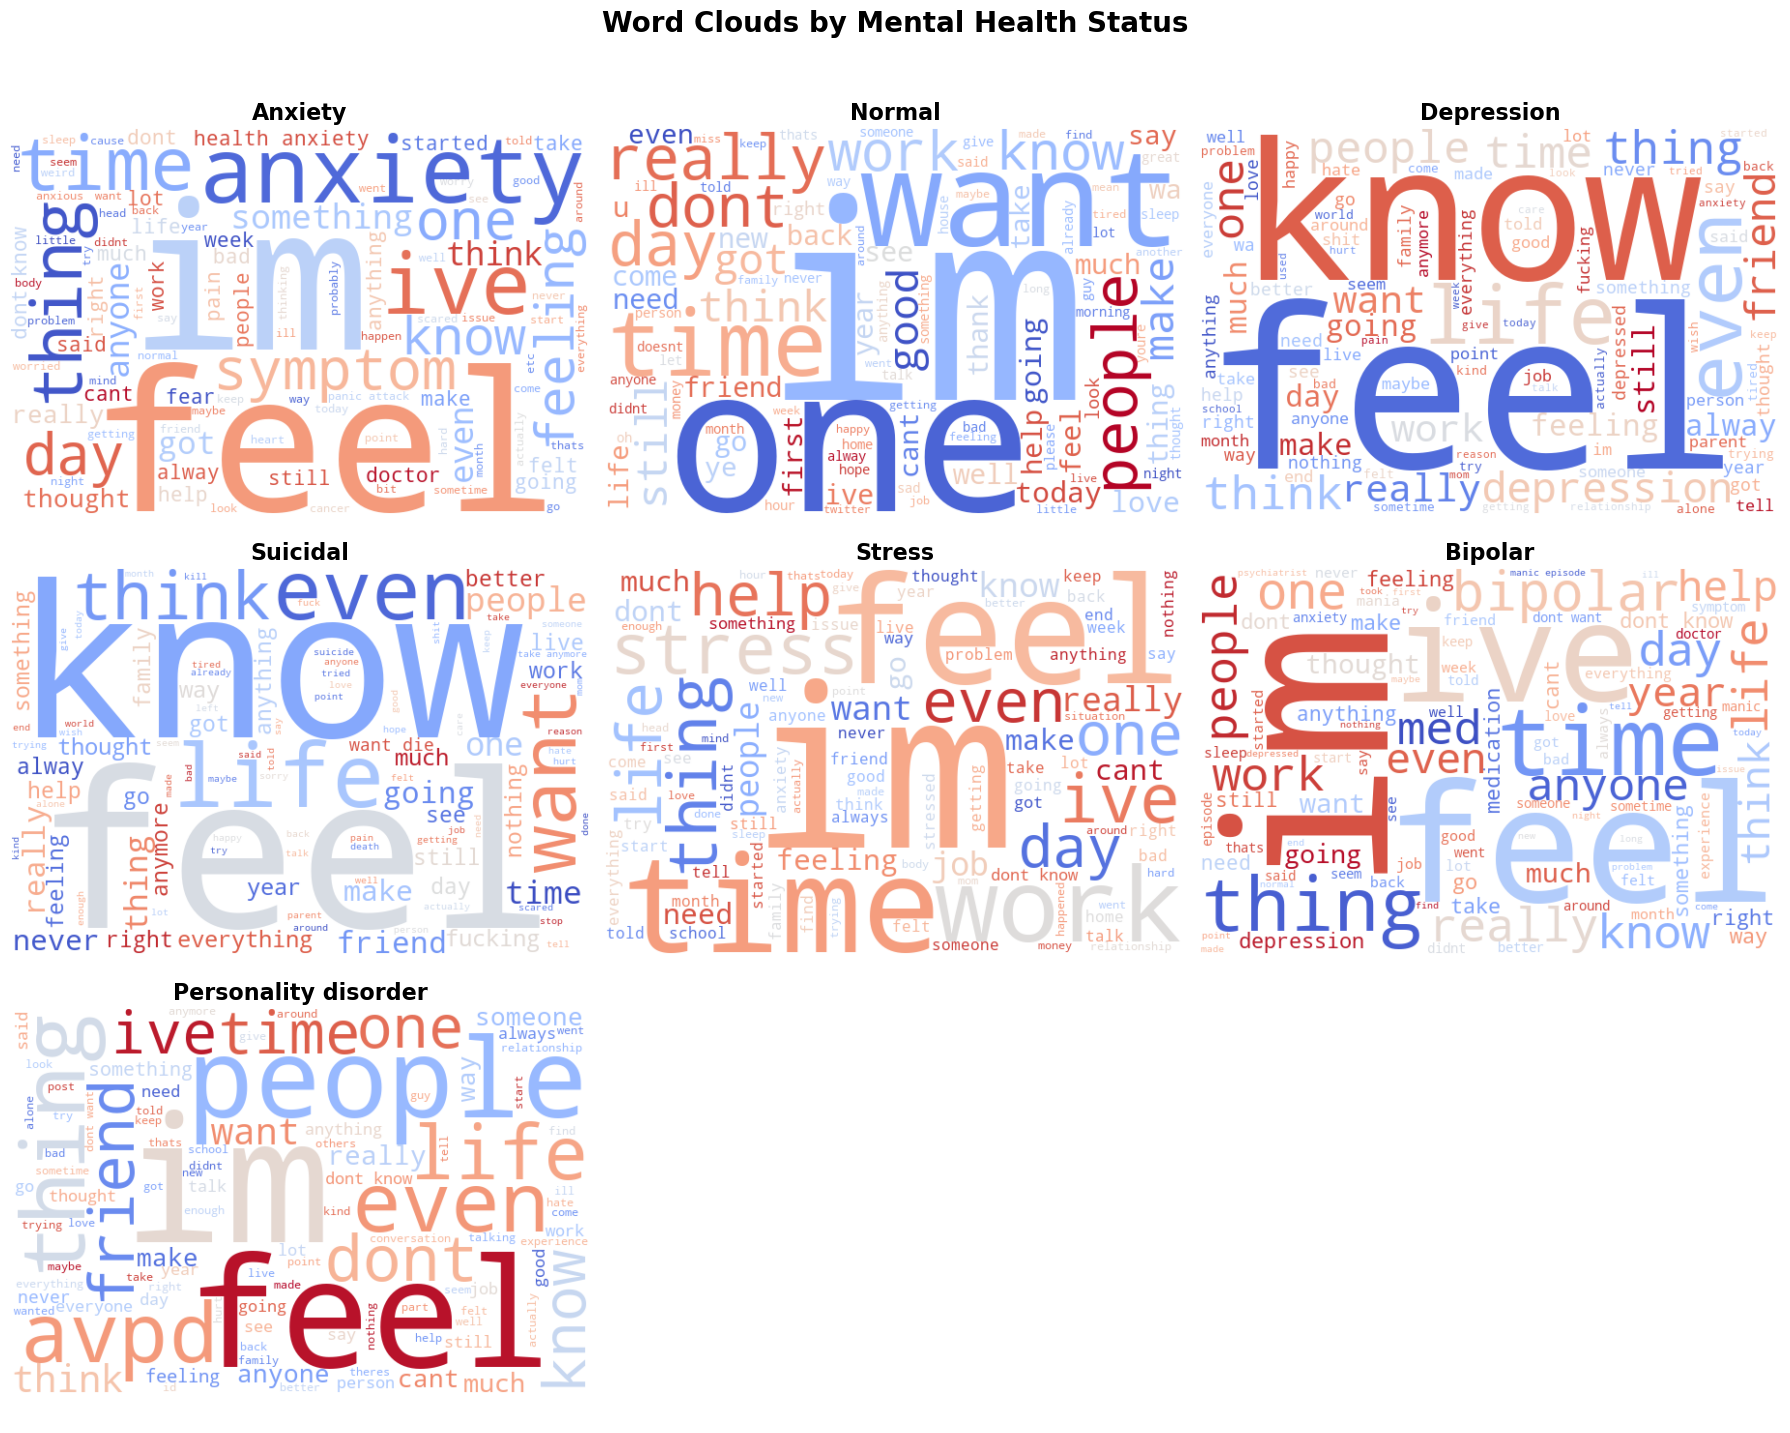

Chart 2 saved!


In [18]:
# Save the word clouds chart
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, status in enumerate(statuses):
    text = ' '.join(df[df['status'] == status]['cleaned_statement'])
    wordcloud = WordCloud(
        width=600,
        height=400,
        background_color='white',
        colormap='coolwarm',
        max_words=100
    ).generate(text)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(status, fontsize=16, fontweight='bold')
    axes[i].axis('off')

for j in range(len(statuses), len(axes)):
    axes[j].axis('off')

plt.suptitle('Word Clouds by Mental Health Status', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, '2_wordclouds.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

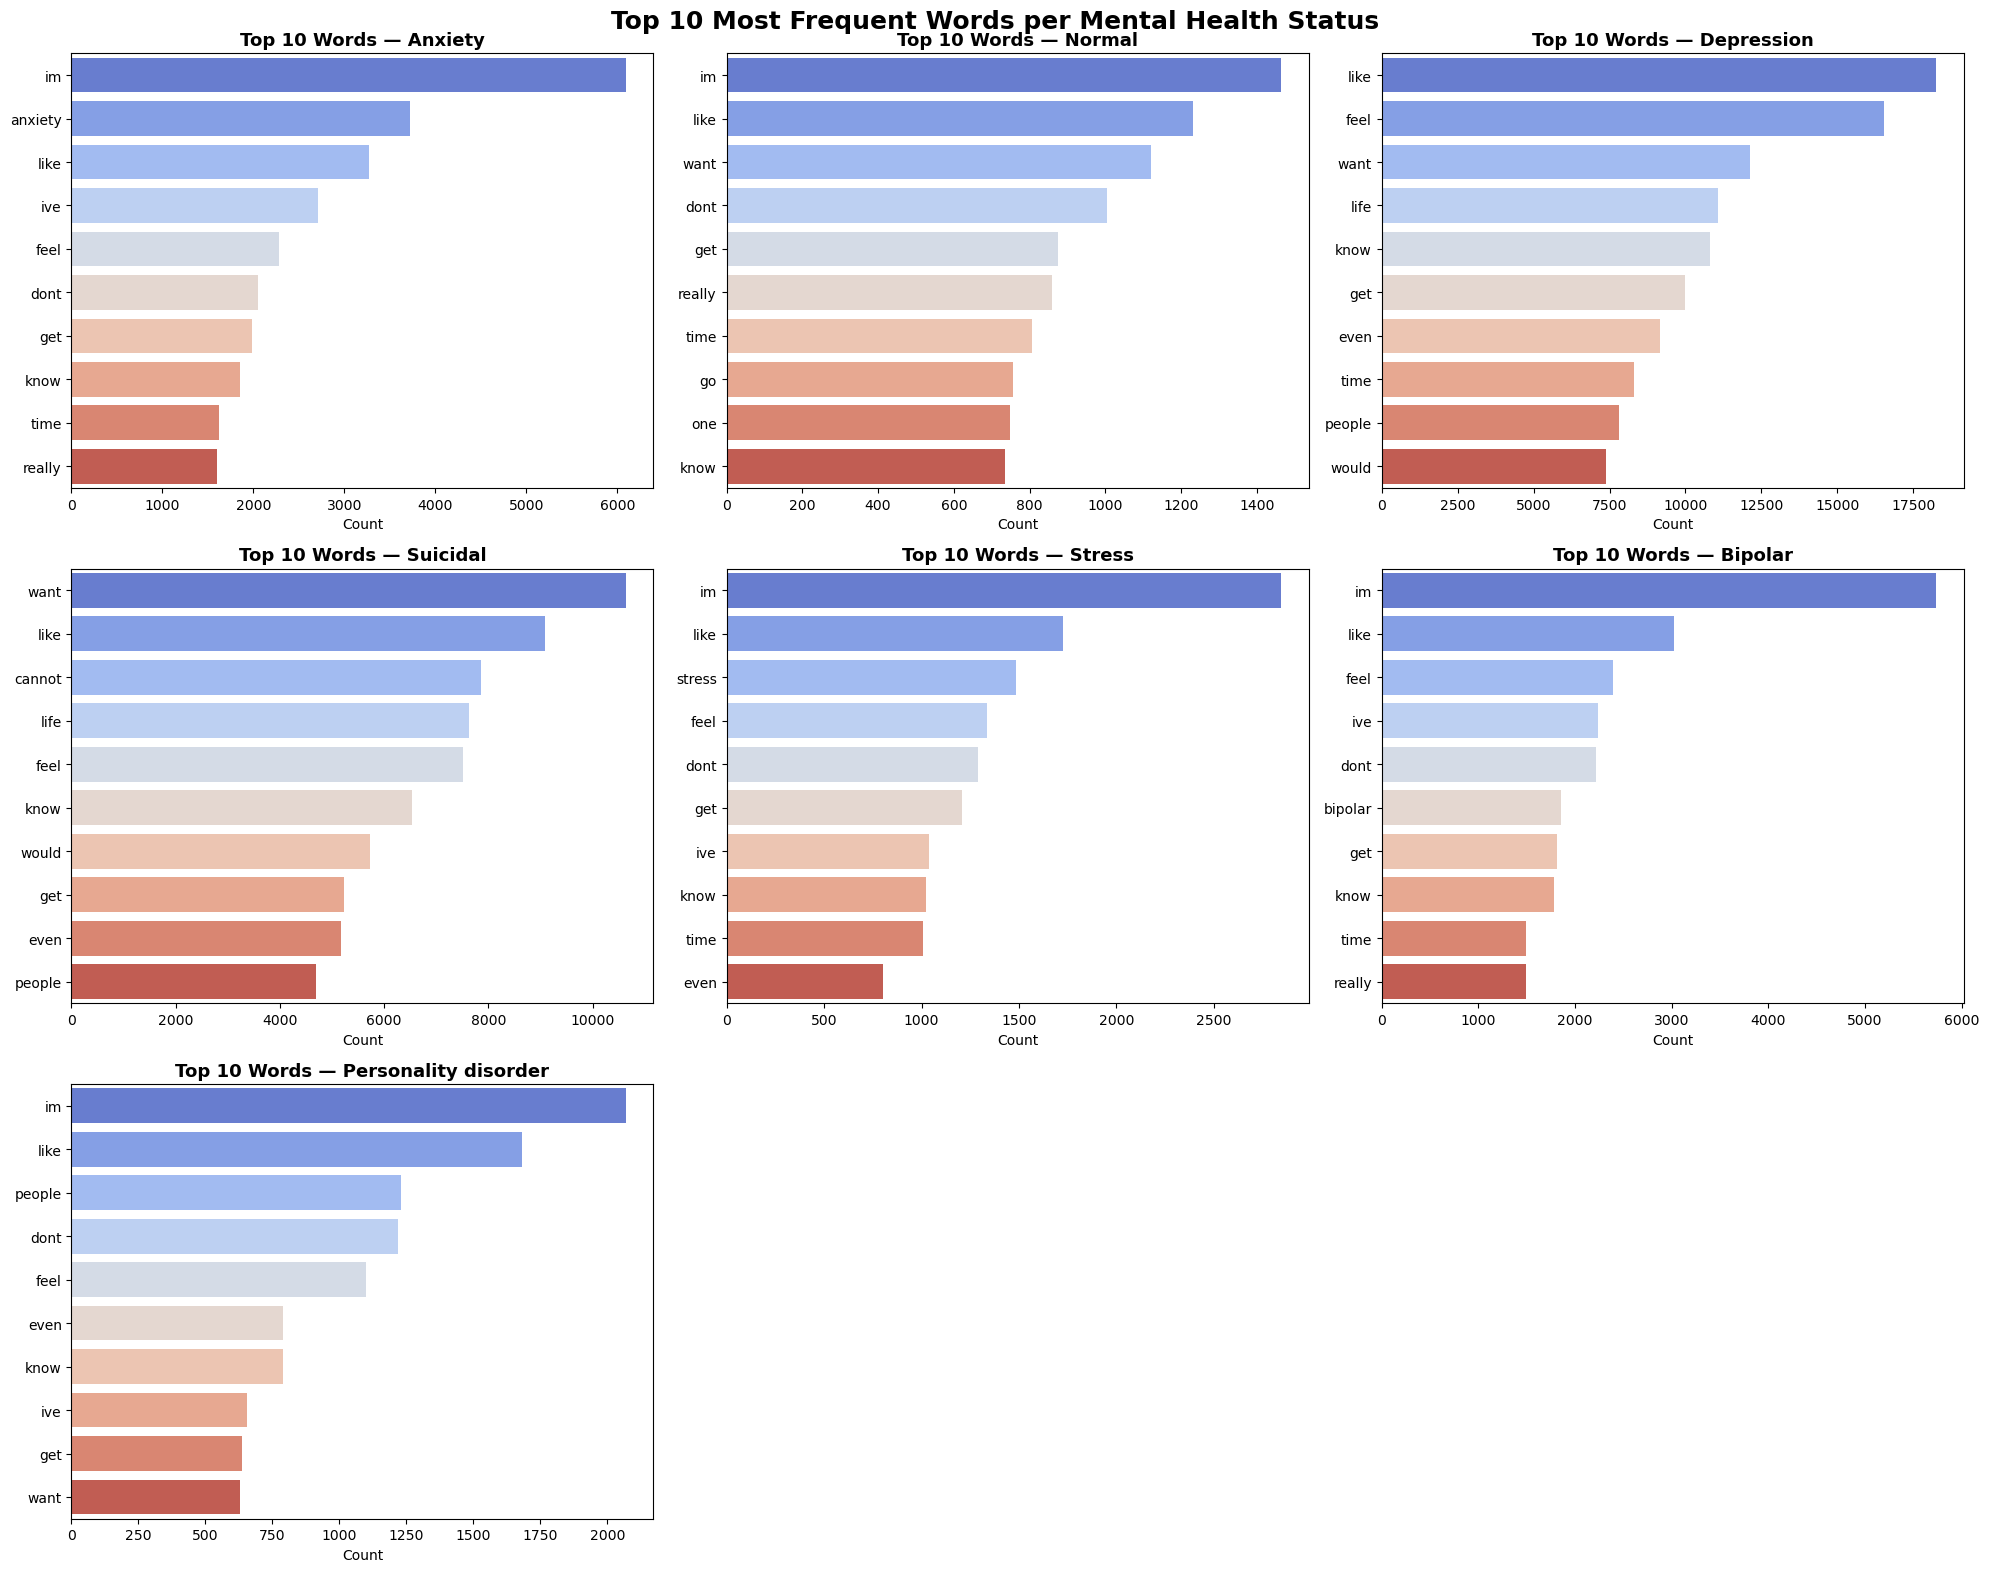

Chart 3 saved!


In [20]:
# Save the top 10 words chart
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for i, status in enumerate(statuses):
    subset = df[df['status'] == status]['cleaned_statement']
    vectorizer = CountVectorizer(max_features=10)
    word_counts = vectorizer.fit_transform(subset)
    words = vectorizer.get_feature_names_out()
    counts = word_counts.toarray().sum(axis=0)
    sorted_idx = counts.argsort()[::-1]
    words = words[sorted_idx]
    counts = counts[sorted_idx]
    sns.barplot(x=counts, y=words, palette='coolwarm', ax=axes[i])
    axes[i].set_title(f'Top 10 Words — {status}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

for j in range(len(statuses), len(axes)):
    axes[j].axis('off')

plt.suptitle('Top 10 Most Frequent Words per Mental Health Status', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_folder, '3_top10_words.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

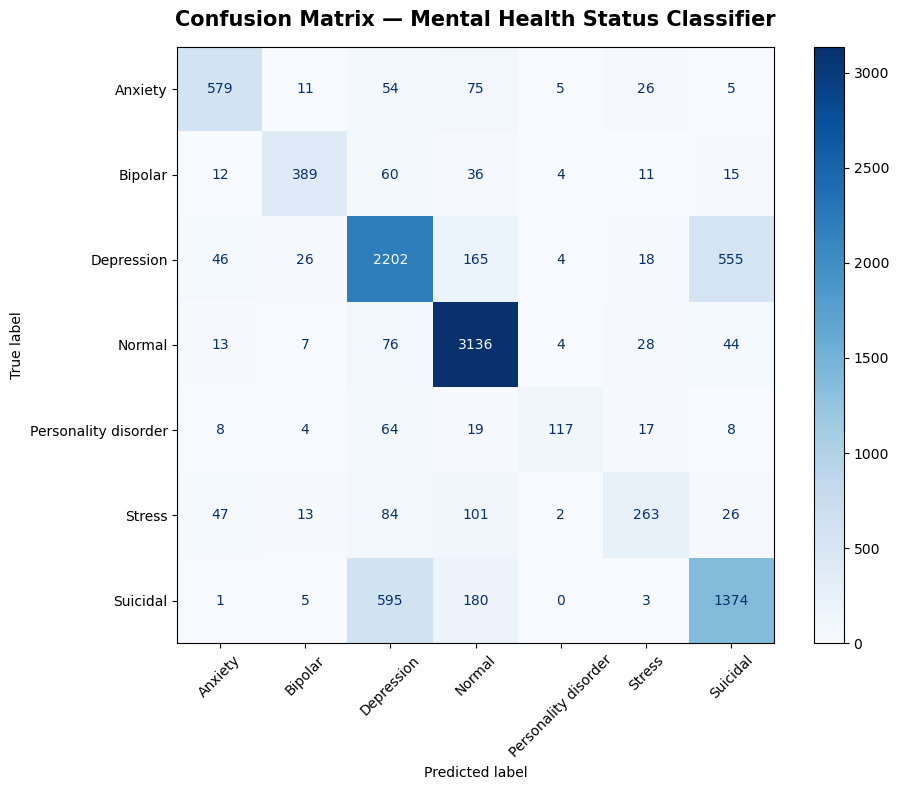

Chart 4 saved!


In [21]:
# Save the confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=model.classes_,
    cmap='Blues',
    ax=ax,
    xticks_rotation=45
)

ax.set_title('Confusion Matrix — Mental Health Status Classifier',
             fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, '4_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

In [22]:
# Verify all charts are saved
saved_files = os.listdir(output_folder)
print("Files saved in charts folder:")
for file in saved_files:
    print(" -", file)

Files saved in charts folder:
 - 1_status_distribution.png
 - 2_wordclouds.png
 - 3_top10_words.png
 - 4_confusion_matrix.png
